In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [51]:
jobs = pd.read_csv("../etl/jobs_clean.csv")
skills = pd.read_csv("../etl/jobs_skills.csv")
features = pd.read_csv("../etl/jobs_features.csv")

df = jobs.merge(features, on="id")

df.head()

,id,companyName,title,seniority_score_x,area,location,has_ml,has_cloud,has_backend,seniority_score_y
0,4402063991,Itaú Unibanco,Desenvolvimento Dynamics Sênior,1,data,"São Paulo, São Paulo, Brazil (On-site)",False,True,True,1
1,4400250820,Itaú Unibanco,Engenharia de Software Frontend Angular Sr | A...,3,data,"São Paulo, São Paulo, Brazil (Hybrid)",False,True,False,3
2,4385160370,Nubank,Senior Software Engineer,3,data,Greater Rio de Janeiro (Hybrid),True,True,False,3
3,4390686657,Nubank,Senior IT Engineer – Global Offices Network,3,data,"São Paulo, São Paulo, Brazil (Hybrid)",True,False,False,3
4,4389407164,Nubank,Senior Media BI Specialist,3,data,"São Paulo, São Paulo, Brazil (Hybrid)",True,False,False,3


In [52]:
print("Total vagas:", len(df))
print("\nEmpresas:")
print(df["companyName"].value_counts())

Total vagas: 215

Empresas:
companyName
Nubank                  104
Inter                    35
Itaú Unibanco            28
Mercado Livre Brasil     25
iFood                    23
Name: count, dtype: int64


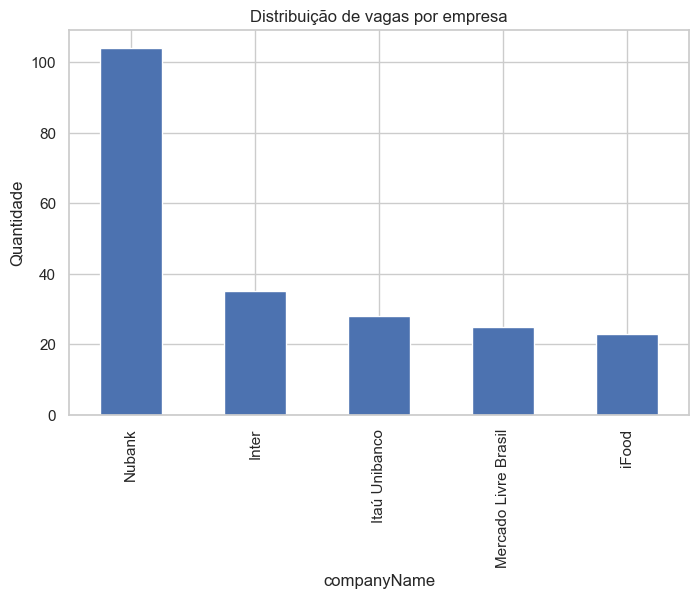

In [53]:
plt.figure(figsize=(8,5))
df["companyName"].value_counts().plot(kind="bar")
plt.title("Distribuição de vagas por empresa")
plt.ylabel("Quantidade")
plt.show()

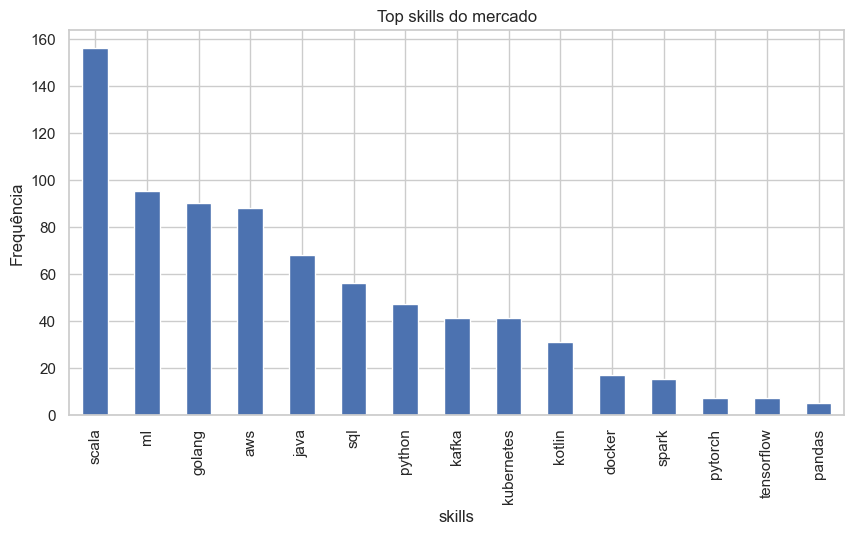

In [55]:
top_skills = skills["skills"].value_counts().head(15)

plt.figure(figsize=(10,5))
top_skills.plot(kind="bar")
plt.title("Top skills do mercado")
plt.ylabel("Frequência")
plt.show()

In [56]:
skills_by_company = (
    skills.merge(jobs[["id", "companyName"]], on="id")
    .groupby(["companyName", "skills"])
    .size()
    .reset_index(name="count")
)

# normalizar (%)
total_by_company = skills_by_company.groupby("companyName")["count"].transform("sum")
skills_by_company["pct"] = skills_by_company["count"] / total_by_company

skills_by_company.sort_values(["companyName","pct"], ascending=False).head(20)

,companyName,skills,count,pct
50,iFood,golang,21,0.164062
57,iFood,scala,17,0.132812
53,iFood,kotlin,13,0.101562
51,iFood,java,12,0.093750
48,iFood,aws,11,0.085938
49,iFood,docker,10,0.078125
54,iFood,kubernetes,10,0.078125
59,iFood,sql,10,0.078125
52,iFood,kafka,7,0.054688
55,iFood,ml,7,0.054688


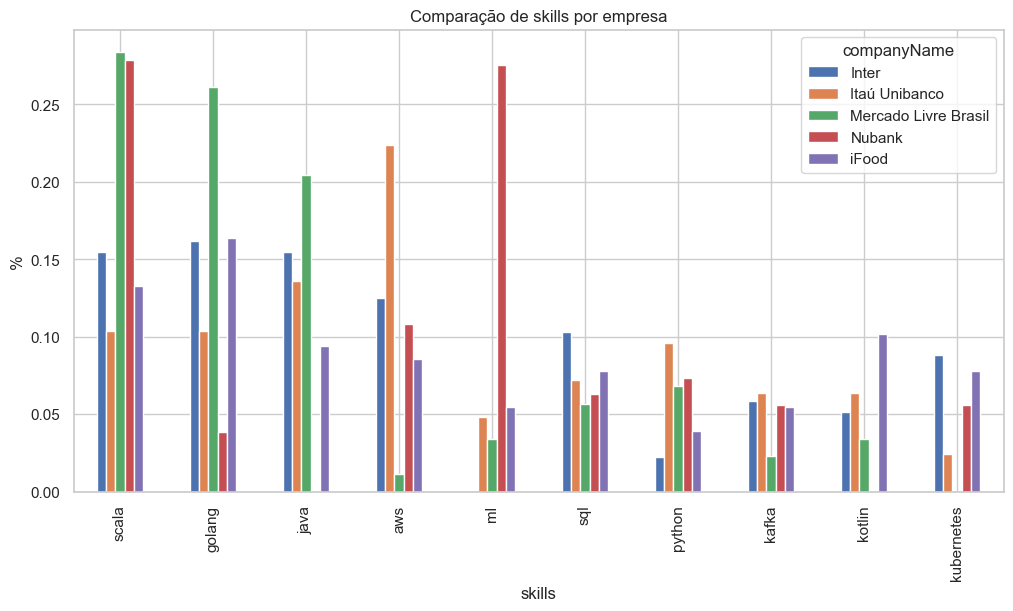

In [57]:
pivot = skills_by_company.pivot_table(
    index="skills",
    columns="companyName",
    values="pct"
).fillna(0)

top = pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot.loc[top].plot(kind="bar", figsize=(12,6))

plt.title("Comparação de skills por empresa")
plt.ylabel("%")
plt.show()

In [58]:
feature_means = df.groupby("companyName")[[
    "has_ml", "has_cloud", "has_backend"
]].mean()

feature_means

,has_ml,has_cloud,has_backend
companyName,,,
Inter,0.000000,0.485714,0.771429
Itaú Unibanco,0.214286,1.000000,0.607143
Mercado Livre Brasil,0.120000,0.040000,0.720000
Nubank,0.759615,0.298077,0.000000
iFood,0.304348,0.478261,0.695652


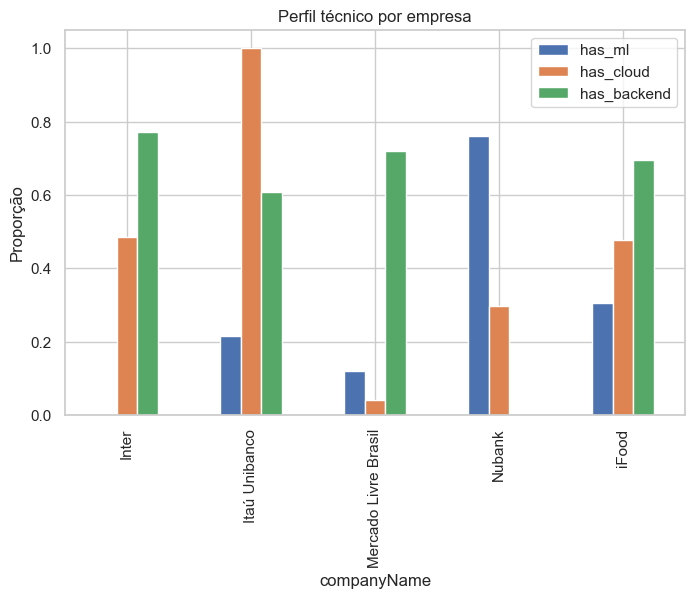

In [59]:
feature_means.plot(kind="bar", figsize=(8,5))
plt.title("Perfil técnico por empresa")
plt.ylabel("Proporção")
plt.show()

In [60]:
df.groupby("seniority_score_x")[[
    "has_ml", "has_cloud", "has_backend"
]].mean()

,has_ml,has_cloud,has_backend
seniority_score_x,,,
1,0.238636,0.477273,0.488636
2,1.000000,0.500000,1.000000
3,0.491803,0.459016,0.409836
4,0.656250,0.265625,0.125000


In [61]:
df["area"].value_counts()

area
data        166
backend      44
other         4
frontend      1
Name: count, dtype: int64

In [ ]:
def generate_insights(df):
    insights = []

    # skill dominante
    top_skill = skills["skills"].value_counts().idxmax()
    insights.append(f"Skill mais demandada: {top_skill}")

    # empresa mais ML
    ml_company = df.groupby("companyName")["has_ml"].mean().idxmax()
    insights.append(f"Empresa mais orientada a ML: {ml_company}")

    # senioridade média
    senior_avg = df["seniority_score_x"].mean()
    insights.append(f"Senioridade média do mercado: {round(senior_avg,2)}")

    return insights

generate_insights(df)

['Skill mais demandada: scala',
 'Empresa mais orientada a ML: Nubank',
 'Senioridade média do mercado: 2.47']